## ニューラルネットワークとQ学習

状態をone-hot-vectorで表現

In [1]:
import numpy as np

def _one_hot(state):
    HEIGHT, WIDTH = 3, 4
    vec = np.zeros(HEIGHT*WIDTH, dtype=np.float32)
    y, x = state
    idx = WIDTH * y + x
    vec[idx] = 1.0
    return vec[np.newaxis, :] # (B, H*W) バッチ対応


# 確認
state = (2,0)
x = _one_hot(state)
print(x.shape)
print(x)

(1, 12)
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]


In [2]:
from collections import defaultdict

Q = defaultdict(lambda: 0)# テーブル
state = (2,0)
action = 0

print(Q[state,action]) # 0.0

0


In [3]:
# 描画用
import numpy as np
import matplotlib
import matplotlib_inline
import matplotlib.pyplot as plt

class Renderer:
    def __init__(self, reward_map, goal_state, wall_state):
        self.reward_map = reward_map
        self.goal_state = goal_state
        self.wall_state = wall_state
        self.ys = len(self.reward_map)
        self.xs = len(self.reward_map[0])

        self.ax = None
        self.fig = None
        self.first_flg = True

    def set_figure(self, figsize=None):
        fig = plt.figure(figsize=figsize)
        self.ax = fig.add_subplot(111)
        ax = self.ax
        ax.clear()
        ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)
        ax.set_xticks(range(self.xs))
        ax.set_yticks(range(self.ys))
        ax.set_xlim(0, self.xs)
        ax.set_ylim(0, self.ys)
        ax.grid(True)

    def render_v(self, v=None, policy=None, print_value=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax

        if v is not None:
            color_list = ['red', 'white', 'green']
            cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
                'colormap_name', color_list)

            # dict -> ndarray
            v_dict = v
            v = np.zeros(self.reward_map.shape)
            for state, value in v_dict.items():
                v[state] = value

            vmax, vmin = v.max(), v.min()
            vmax = max(vmax, abs(vmin))
            vmin = -1 * vmax
            vmax = 1 if vmax < 1 else vmax
            vmin = -1 if vmin > -1 else vmin

            ax.pcolormesh(np.flipud(v), cmap=cmap, vmin=vmin, vmax=vmax)

        for y in range(ys):
            for x in range(xs):
                state = (y, x)
                r = self.reward_map[y, x]
                if r != 0 and r is not None:
                    txt = 'R ' + str(r)
                    if state == self.goal_state:
                        txt = txt + ' (GOAL)'
                    ax.text(x+.1, ys-y-0.9, txt)

                if (v is not None) and state != self.wall_state:
                    if print_value:
                        offsets = [(0.4, -0.15), (-0.15, -0.3)]
                        key = 0
                        if v.shape[0] > 7: key = 1
                        offset = offsets[key]
                        ax.text(x+offset[0], ys-y+offset[1], "{:12.2f}".format(v[y, x]))

                if policy is not None and state != self.wall_state:
                    actions = policy[state]
                    max_actions = [kv[0] for kv in actions.items() if kv[1] == max(actions.values())]

                    arrows = ["↑", "↓", "←", "→"]
                    offsets = [(0, 0.1), (0, -0.1), (-0.1, 0), (0.1, 0)]
                    for action in max_actions:
                        arrow = arrows[action]
                        offset = offsets[action]
                        if state == self.goal_state:
                            continue
                        ax.text(x+0.45+offset[0], ys-y-0.5+offset[1], arrow)

                if state == self.wall_state:
                    ax.add_patch(plt.Rectangle((x,ys-y-1), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
        plt.show()

    def render_q(self, q, show_greedy_policy=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax
        action_space = [0, 1, 2, 3]

        qmax, qmin = max(q.values()), min(q.values())
        qmax = max(qmax, abs(qmin))
        qmin = -1 * qmax
        qmax = 1 if qmax < 1 else qmax
        qmin = -1 if qmin > -1 else qmin


        color_list = ['red', 'white', 'green']
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
            'colormap_name', color_list)

        for y in range(ys):
            for x in range(xs):
                for action in action_space:
                    state = (y, x)
                    r = self.reward_map[y, x]
                    if r != 0 and r is not None:
                        txt = 'R ' + str(r)
                        if state == self.goal_state:
                            txt = txt + ' (GOAL)'
                        ax.text(x+.05, ys-y-0.95, txt)

                    if state == self.goal_state:
                        continue

                    tx, ty = x, ys-y-1

                    action_map = {
                        0: ((0.5+tx, 0.5+ty), (tx+1, ty+1), (tx, ty+1)),
                        1: ((tx, ty), (tx+1, ty), (tx+0.5, ty+0.5)),
                        2: ((tx, ty), (tx+0.5, ty+0.5), (tx, ty+1)),
                        3: ((0.5+tx, 0.5+ty), (tx+1, ty), (tx+1, ty+1)),
                    }
                    offset_map = {
                        0: (0.1, 0.8),
                        1: (0.1, 0.1),
                        2: (-0.2, 0.4),
                        3: (0.4, 0.4),
                    }
                    if state == self.wall_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
                    elif state in self.goal_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0., 1., 0., 1.)))
                    else:

                        tq = q[(state, action)]
                        color_scale = 0.5 + (tq / qmax) / 2  # normalize: 0.0-1.0

                        poly = plt.Polygon(action_map[action],fc=cmap(color_scale))
                        ax.add_patch(poly)

                        offset= offset_map[action]
                        ax.text(tx+offset[0], ty+offset[1], "{:12.2f}".format(tq))
        plt.show()

        if show_greedy_policy:
            policy = {}
            for y in range(self.ys):
                for x in range(self.xs):
                    state = (y, x)
                    qs = [q[state, action] for action in range(4)]  # action_size
                    max_action = np.argmax(qs)
                    probs = {0:0.0, 1:0.0, 2:0.0, 3:0.0}
                    probs[max_action] = 1
                    policy[state] = probs
            self.render_v(None, policy)

In [5]:
import numpy as np

class GridWorld:
    def __init__(self):
        self.action_space = [0,1,2,3]
        self.action_meaning = {
            0: 'UP', 1: 'DOWN', 2: 'LEFT', 3: 'RIGHT'
        }

        # 報酬マップ
        self.reward_map = np.array([
            [0, 0, 0, 1.0],
            [0, None, 0, -1.0],
            [0, 0, 0, 0]
        ])

        self.goal_state = (0,3) # reward: 1.0
        self.wall_state = (1,1) # None
        self.start_state = (2,0) # 左下隅
        self.agent_state = self.start_state

    @property
    def height(self):
        return len(self.reward_map)
    
    @property
    def width(self):
        return len(self.reward_map[0])
    
    @property
    def shape(self):
        return self.reward_map.shape
    
    def actions(self):
        return self.action_space
    
    # ジェネレータ
    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield (h,w)

    # 状態遷移関数
    def next_state(self, state, action): # p(s'|s,a)
        # print(f'state: {state}')

        # 1. 移動先の場所の計算
        action_move_map = [
            (-1,0), # 上
            (1,0),  # 下
            (0,-1), # 左
            (0,1)   # 右
        ]
        move = action_move_map[action]
        # print(f'move: {move}')
        next_state = (state[0] + move[0], state[1] + move[1])
        # print(f'next_state: {next_state}')
        ny, nx = next_state

        # 2. 移動先がグリッドワールドの枠の外か、それとも移動先が壁か?
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height:
            next_state = state
        elif next_state == self.wall_state:
            next_state = state

        return next_state # 3. 状態遷移は決定論的なので関数の結果を返すだけ.
    
    # 報酬関数
    def reward(self, state, action, next_state): # r(s',s,a)
        # 今回はエージェントの行動や前回の状態ｓに依存はなく、状態遷移後の状態s'のみに報酬は依存する
        return self.reward_map[next_state]
    
    def reset(self):
        self.agent_state = self.start_state
        return self.agent_state
    
    # エージェントに方策πに従って一つ行動させる
    def step(self, action):
        state = self.agent_state
        next_state = self.next_state(state, action) # 状態遷移
        reward = self.reward(state, action, next_state) # 得られた報酬
        done = (next_state == self.goal_state) # 収束条件

        self.agent_state = next_state # エージェントが置かれた状態を更新
        return next_state, reward, done
    
    def render_v(self, v=None, policy=None, print_value=True):
        # 状態価値Vの可視化
        renderer = Renderer(self.reward_map,
                                            self.goal_state,
                                            self.wall_state)
        renderer.render_v(v, policy, print_value)

    def render_q(self, q=None, print_value=True):
        # 行動価値Qの可視化
        renderer = Renderer(self.reward_map,
                                          self.goal_state,
                                          self.wall_state)
        renderer.render_q(q, print_value)

In [6]:
import torch

# CPUではなくMacのGPU(MPS)を使う設定
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [8]:
def one_hot(state, height=3, width=4):
    # 1. 状態をインデックスに変換 (例: (2,0) -> 8)
    index = state[0] * width + state[1]
    
    # 2. ワンホットベクトルを作成
    vec = np.zeros(height * width, dtype=np.float32)
    vec[index] = 1.0
    
    # 3. PyTorchのテンソルに変換し、バッチ次元(1, 12)を追加する
    # nn.Linearは「(バッチサイズ, 入力サイズ)」の形を期待するため
    return torch.from_numpy(vec).unsqueeze(0)

In [9]:
# 確認
state = (2,0)
x = one_hot(state)
print(x.shape)
print(x)

torch.Size([1, 12])
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])


In [10]:
import torch.nn as nn
import torch.nn.functional as F


class QNet(nn.Module):
    def __init__(self, height: int = 3, width: int = 4, action_size: int = 4):
        super().__init__()
        hidden_size = 100
        self.l1 = nn.Linear(in_features=height*width, out_features=hidden_size) # 中間サイズ
        self.l2 = nn.Linear(in_features=hidden_size, out_features=action_size)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)
        return x
    
qnet = QNet()

state = (2,0)
state = one_hot(state)

qs = qnet(state)
print(qs.shape)
print(qs)

torch.Size([1, 4])
tensor([[ 0.2158,  0.0119, -0.0679,  0.0885]], grad_fn=<AddmmBackward0>)


#### Q関数をニューラルネットワークに置き換える
$$Q'_{\pi}(S_{t},A_{t}) = Q_{\pi}(S_{t},A_{t}) + \alpha \{ R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1}) - Q_{\pi}(S_{t},A_{t}) \}$$
+ ターゲット: $T = R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1})$
  
$$Q'_{\pi}(S_{t},A_{t}) = Q_{\pi}(S_{t},A_{t}) + \alpha \{ T - Q_{\pi}(S_{t},A_{t}) \}$$
+ ターゲットT: ニューラルネットワークの正解ラベル(推定値:ブートストラップ)
+ 入力: $(S_t,A_t)$, 出力: Tを出力するニューラルネットワークにできる
+ これはブートストラップなニューラルネットワークに置き換え可能

In [11]:
import torch.optim as optim

class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.lr = 0.01
        self.epsilon = 0.1
        self.action_size = 4

        self.qnet = QNet()
        self.optimizer = optim.Adam(self.qnet.parameters(), lr=self.lr)
        

    def get_action(self, state):
        # サンプリングモデルのため、ターゲット方策π(a|s): (活用), 挙動方策b(a|s): (探索)は陰的表現になる
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            qs = self.qnet(state) # 方策とQ関数の融合=NN
            return torch.argmax(qs.detach().cpu(), dim=1).item()
        
    def update(self, state, action, reward, next_state, done):
        done = int(done)
        # print(f"done: {done}")
        next_qs = self.qnet(next_state).detach()
        # print(f"next_qs: {next_qs}")
        next_q = torch.max(next_qs, dim=1)[0] # 次の状態における最大行動価値Q
        # print(f"next_q: {next_q}")

        target = reward + (1 - done) * self.gamma * next_q
        qs = self.qnet(state)
        q = qs[:, action]
        loss = F.mse_loss(target, q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

In [17]:
env = GridWorld()
agent = QLearningAgent()

episodes = 10000
loss_history = []

for episode in range(episodes):
    state = env.reset()
    state = one_hot(state)
    total_loss, cnt = 0, 0
    done = False

    while not done:
        action = agent.get_action(state)
        # print(f"action: {action}")
        # break
        next_state, reward, done = env.step(action)
        next_state = one_hot(next_state)
        # print(f"next_state: {next_state}")
        # print(f"reward: {reward}")
        # print(f"done: {done}")
        # break

        loss = agent.update(state, action, reward, next_state, done)
        # print(f"loss: {loss}")
        # break

        total_loss += loss
        cnt += 1
        state = next_state

    average_loss = total_loss / cnt
    loss_history.append(average_loss)

print('loss_history:¥n')
print(loss_history)
print(len(loss_history))


loss_history:¥n
[0.058397429175740805, 0.037547391126850016, 0.09050700028828942, 0.016253297088301873, 0.022080269921571017, 0.03130451107863337, 0.3780734598336234, 0.0623048291541636, 0.08736089400481432, 0.06706239711493253, 0.031380663299933075, 0.04373954278222906, 0.062259340984746815, 0.08020558907446684, 0.10449767894377666, 0.04487975649535656, 0.1234163953922689, 0.04375982295023277, 0.0662916149944067, 0.034744973108172414, 0.02188758931006305, 0.06872593791922554, 0.024000788855898594, 0.01857040450785361, 0.020026050905774657, 0.012132462146519174, 0.04800116159354469, 0.019575969126890413, 0.014573684148490428, 0.012599977850914, 0.04668829421279952, 0.032028781506232916, 0.020204462693072855, 0.010217511141672731, 0.032622167727608675, 0.09524330862332135, 0.01572695601498708, 0.04799146467667015, 0.019118797781993636, 0.010553455091576324, 0.006446018426504452, 0.053157059529136554, 0.012322803898860002, 0.014234793925425038, 0.02351876425174331, 0.006532939781512444, 

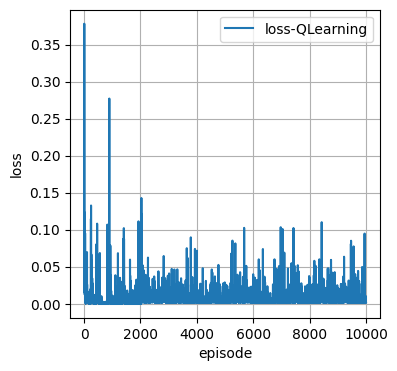

In [18]:
x = np.arange(0, len(loss_history))
y = np.array(loss_history, dtype=np.float32)

fig = plt.figure(figsize=(4,4))
plt.plot(x, y, label='loss-QLearning')
plt.xlabel('episode')
plt.ylabel('loss')
plt.legend()
plt.grid()
plt.show()

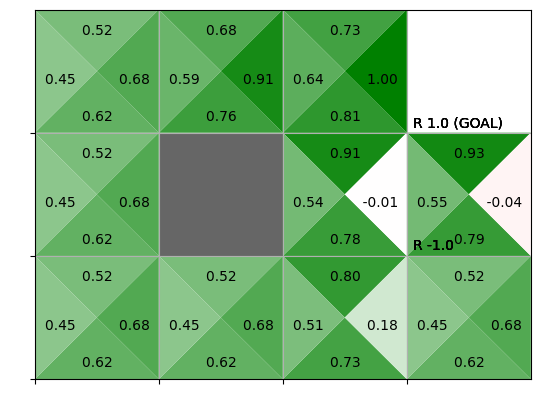

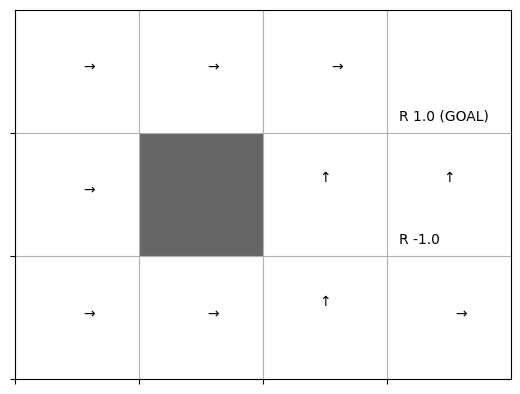

In [19]:
# visualize
Q = {}
for state in env.states():
    for action in env.action_space:
        q = agent.qnet(one_hot(state))[:, action]
        Q[state, action] = float(q.data)
env.render_q(Q)